In [1]:
import pandas as pd
import numpy as np
import math
np.random.seed(7)

In [2]:
df = pd.read_csv('/content/AirPassengers.csv', usecols=[1],engine='python')

In [3]:
dataset = df.values
dataset = dataset.astype('float32')

In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
dataset = scaler.fit_transform(dataset)

In [5]:
dataset

array([[0.01544401],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853],
       [0.05984557],
       [0.08494207],
       [0.08494207],
       [0.06177607],
       [0.02895753],
       [0.        ],
       [0.02702703],
       [0.02123553],
       [0.04247104],
       [0.07142857],
       [0.05984557],
       [0.04054055],
       [0.08687258],
       [0.12741312],
       [0.12741312],
       [0.10424709],
       [0.05598456],
       [0.01930502],
       [0.06949806],
       [0.07915059],
       [0.08880308],
       [0.14285713],
       [0.11389962],
       [0.13127413],
       [0.14285713],
       [0.18339768],
       [0.18339768],
       [0.15444016],
       [0.11196911],
       [0.08108109],
       [0.1196911 ],
       [0.12934363],
       [0.14671814],
       [0.17181468],
       [0.14864865],
       [0.15250966],
       [0.22007722],
       [0.24324325],
       [0.26640925],
       [0.2027027 ],
       [0.16795367],
       [0.13127413],
       [0.173

In [6]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(dataset, test_size=0.33, random_state=42)
print(len(train),len(test))

96 48


In [7]:
train

array([[0.08880308],
       [0.06949806],
       [0.7741313 ],
       [0.36486486],
       [0.2027027 ],
       [0.05984557],
       [0.3899614 ],
       [0.14864865],
       [0.01930502],
       [0.2992278 ],
       [0.40154442],
       [0.7799227 ],
       [0.17374519],
       [0.18339768],
       [0.49999997],
       [0.32046333],
       [0.8320464 ],
       [0.11196911],
       [0.32818535],
       [0.55212355],
       [0.25289574],
       [0.96911204],
       [0.6891892 ],
       [0.26833975],
       [0.05984557],
       [0.33397684],
       [0.4131274 ],
       [0.17760617],
       [0.1196911 ],
       [0.4073359 ],
       [0.08108109],
       [0.58108103],
       [0.08494207],
       [0.26640925],
       [0.1911197 ],
       [0.52123547],
       [0.3359073 ],
       [0.5637065 ],
       [0.5849421 ],
       [0.06177607],
       [0.04247104],
       [0.45559844],
       [0.7471043 ],
       [0.04826255],
       [0.08687258],
       [0.17181468],
       [0.26640925],
       [0.494

In [8]:
#Convert an array of values into a dataset matrix
def create_dataset(dataset,look_back=1):
  dataX, dataY = [],[]
  for i in range(len(dataset)-look_back-1):
    a = dataset[i:(i+look_back),0]
    dataX.append(a)
    dataY.append(dataset[i+look_back,0])
  return np.array(dataX), np.array(dataY)

In [9]:
# reshape into X=t and Y=t+1
look_back = 1
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)
# reshape input to be [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

In [10]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [11]:
from sklearn.metrics import mean_squared_error

In [12]:
model = Sequential()
model.add(LSTM(4, input_shape=(1, look_back)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=2)

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


94/94 - 1s - 15ms/step - loss: 0.1405
Epoch 2/100
94/94 - 0s - 1ms/step - loss: 0.0897
Epoch 3/100
94/94 - 0s - 2ms/step - loss: 0.0684
Epoch 4/100
94/94 - 0s - 1ms/step - loss: 0.0617
Epoch 5/100
94/94 - 0s - 2ms/step - loss: 0.0598
Epoch 6/100
94/94 - 0s - 1ms/step - loss: 0.0590
Epoch 7/100
94/94 - 0s - 2ms/step - loss: 0.0590
Epoch 8/100
94/94 - 0s - 2ms/step - loss: 0.0585
Epoch 9/100
94/94 - 0s - 3ms/step - loss: 0.0587
Epoch 10/100
94/94 - 0s - 3ms/step - loss: 0.0585
Epoch 11/100
94/94 - 0s - 2ms/step - loss: 0.0584
Epoch 12/100
94/94 - 0s - 1ms/step - loss: 0.0579
Epoch 13/100
94/94 - 0s - 3ms/step - loss: 0.0579
Epoch 14/100
94/94 - 0s - 1ms/step - loss: 0.0576
Epoch 15/100
94/94 - 0s - 2ms/step - loss: 0.0576
Epoch 16/100
94/94 - 0s - 2ms/step - loss: 0.0577
Epoch 17/100
94/94 - 0s - 2ms/step - loss: 0.0575
Epoch 18/100
94/94 - 0s - 2ms/step - loss: 0.0574
Epoch 19/100
94/94 - 0s - 1ms/step - loss: 0.0573
Epoch 20/100
94/94 - 0s - 1ms/step - loss: 0.0572
Epoch 21/100
94/94 -

In [13]:
#Make prediction
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [14]:
#invert prediction
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])

In [15]:
train_score = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (train_score))
test_score = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (test_score))

Train Score: 122.61 RMSE
Test Score: 113.03 RMSE


In [16]:
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict

In [17]:
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(dataset)-1, :] = testPredict

In [18]:
import matplotlib.pyplot as plt

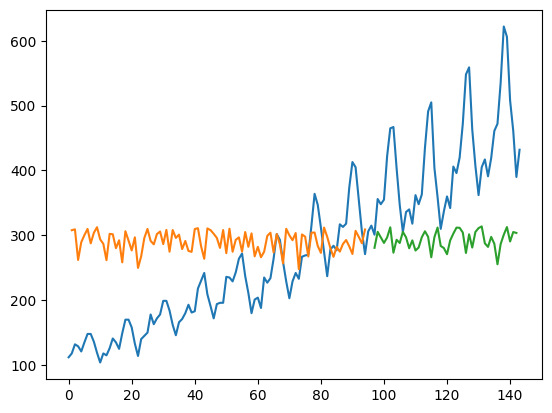

In [19]:
plt.plot(scaler.inverse_transform(dataset))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()